1. Rilevazaione degli outliner tramite clusterizzazione (utilizzare local ouliner factory, mi chiede i k vicini e quale frazione di outliner mi aspetto)
2. Regressione polinomiale
3. Plot della dell'errore e devizione standard


In [177]:
import pandas as pd


df = pd.read_csv('./function_1000_25.csv')


In [178]:
print(df.head())  

          X         y
0  1.872701  2.783879
1  4.753572 -2.698304
2  3.659970 -1.690942
3  2.993292 -0.404486
4  0.780093  0.497187


In [179]:
import matplotlib.pyplot as plt
def plot_data(df):
    plt.figure(figsize=(8, 5))
    plt.scatter(df["X"], df["y"], s=15, alpha=0.7)
    plt.title("Plot dei dati")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.show()

In [180]:
# Outlier detection su DataFrame unificato (nessuno split qui)
print(df.shape)

(1000, 2)


In [181]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=50, contamination='auto')

# LOF sul dataset completo (X, y)
y_pred = clf.fit_predict(df[["X", "y"]])
xscores = clf.negative_outlier_factor_

Soglia score: 1.1
Punti iniziali: 1000
Punti rimossi (score > 1.1): 248
Punti finali: 752


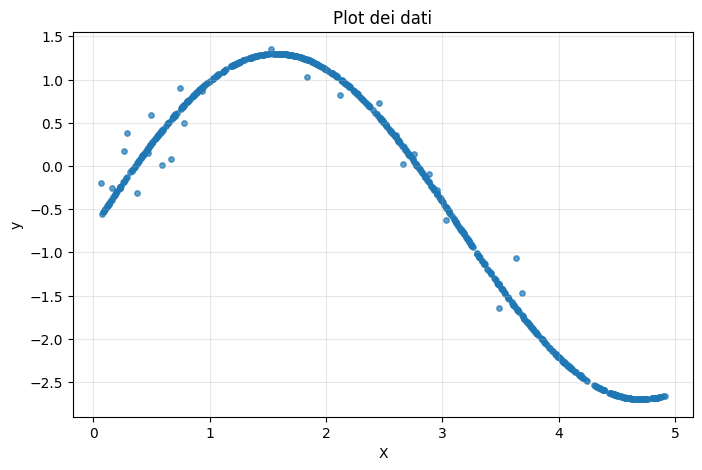

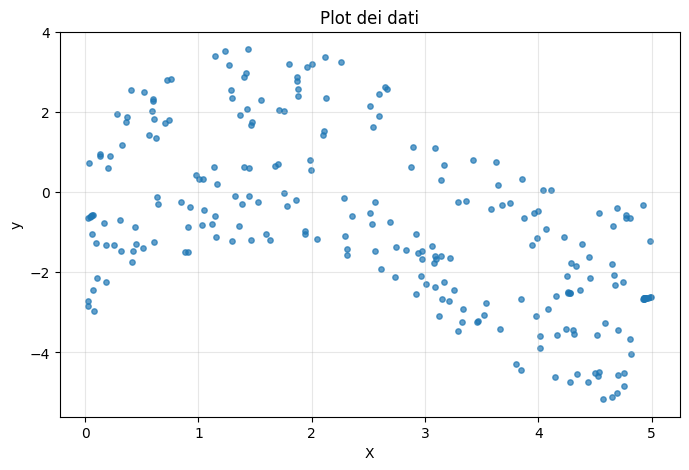

In [182]:
# Score e filtro su DataFrame unificato
threshold = 1.1

df_scores = df.copy()
df_scores["score"] = -xscores

# Mantieni solo i punti con score <= soglia
df_clean = df_scores[df_scores["score"] <= threshold][["X", "y"]].copy()

# Punti rimossi: score > soglia
df_outliers = df_scores[df_scores["score"] > threshold][["X", "y"]].copy()

print(f"Soglia score: {threshold}")
print(f"Punti iniziali: {len(df)}")
print(f"Punti rimossi (score > {threshold}): {len(df_outliers)}")
print(f"Punti finali: {len(df_clean)}")

plot_data(df_clean)
plot_data(df_outliers)


In [183]:
from sklearn.model_selection import train_test_split
X_tr, X_te , y_tr, y_te = train_test_split( df_clean["X"], df_clean["y"], test_size=0.15, random_state=49 )



In [196]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

err_tr_grado = []
err_te_grado = []
std_tr_grado = []
std_te_grado = []

for degree in range(1, 30, 2):
    err_tr_split = []
    err_te_split = []

    for split in range(0, 41, 2):
        X_tr, X_te, y_tr, y_te = train_test_split(df_clean["X"], df_clean["y"], test_size=0.15, random_state=split)
        
        model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())

        X_tr_2d = X_tr.to_numpy().reshape(-1, 1)
        X_te_2d = X_te.to_numpy().reshape(-1, 1)

        model.fit(X_tr_2d, y_tr)
        y_pred_tr = model.predict(X_tr_2d)
        y_pred_te = model.predict(X_te_2d)

        err_tr_split.append(mean_squared_error(y_tr, y_pred_tr))
        err_te_split.append(mean_squared_error(y_te, y_pred_te))

    err_tr_grado.append(np.mean(err_tr_split))
    err_te_grado.append(np.mean(err_te_split))
    std_tr_grado.append(np.std(err_tr_split))
    std_te_grado.append(np.std(err_te_split))



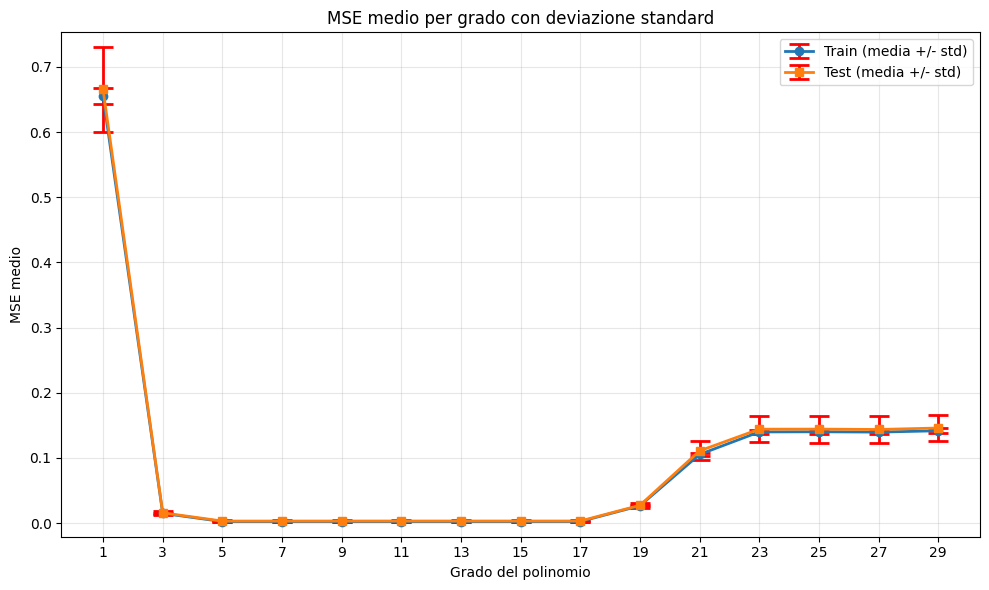

In [197]:
# Unico plot: MSE medio con baffi = deviazione standard in ogni punto
gradi_plot = list(range(1, 1 + 2 * len(err_tr_grado), 2))

# Zoom y piu aggressivo
all_lower = [m - s for m, s in zip(err_tr_grado, std_tr_grado)] + [m - s for m, s in zip(err_te_grado, std_te_grado)]
all_upper = [m + s for m, s in zip(err_tr_grado, std_tr_grado)] + [m + s for m, s in zip(err_te_grado, std_te_grado)]
y_min = min(all_lower)
y_max = max(all_upper)
pad = 0.03 * (y_max - y_min) if y_max > y_min else 0.005

plt.figure(figsize=(10, 6))
plt.errorbar(
    gradi_plot,
    err_tr_grado,
    yerr=std_tr_grado,
    fmt='o-',
    markersize=6,
    linewidth=2,
    ecolor='red',
    elinewidth=2.0,
    capsize=7,
    capthick=2.0,
    errorevery=1,
    label='Train (media +/- std)',
    zorder=3
)
plt.errorbar(
    gradi_plot,
    err_te_grado,
    yerr=std_te_grado,
    fmt='s-',
    markersize=6,
    linewidth=2,
    ecolor='red',
    elinewidth=2.0,
    capsize=7,
    capthick=2.0,
    errorevery=1,
    label='Test (media +/- std)',
    zorder=3
)

plt.title('MSE medio per grado con deviazione standard')
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE medio')
plt.xticks(gradi_plot)
plt.ylim(y_min - pad, y_max + pad)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()